# SmartVision AI — Data Understanding, EDA & Preprocessing

## Objective

This notebook focuses on understanding, analyzing, and preparing the SmartVision image dataset before model training.

### Main Tasks

- Understand the dataset structure
- Analyze class distribution and class balance
- Analyze train, validation, and test splits
- Examine image dimensions and image quality
- Visualize representative images
- Analyze detection/object information
- Identify duplicate images and potential data leakage
- Prepare images for classification
- Resize images to 224 × 224 pixels
- Normalize image data
- Apply data augmentation

The prepared dataset will be used in the CNN classification and YOLO object detection stages.

In [1]:

from pathlib import Path
from collections import Counter
import json
import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
import cv2

from tqdm import tqdm

In [2]:
# Define project dataset paths

DATA_DIR = Path("../data/raw/smartvision_dataset")

CLASSIFICATION_DIR = DATA_DIR / "classification"
DETECTION_DIR = DATA_DIR / "detection"

# 2. Exploratory Data Analysis (EDA)

EDA is performed to understand the structure, distribution, quality, and characteristics of the SmartVision dataset before preprocessing and model training.

### EDA Objectives

- Analyze the number of classes
- Analyze class distribution
- Verify train/validation/test distribution
- Check image dimensions
- Check image channels and quality
- Visualize sample images
- Analyze object/detection information
- Identify duplicate images and possible data leakage

## 2.1 Class Distribution

Analyze the number of images available for each class across the train, validation, and test splits.

In [3]:
# Count images available in each class for every dataset split

splits = ["train", "val", "test"]

class_counts = {}

for split in splits:
    split_dir = CLASSIFICATION_DIR / split

    class_counts[split] = {
        class_dir.name: len(list(class_dir.glob("*")))
        for class_dir in split_dir.iterdir()
        if class_dir.is_dir()
    }

class_counts

{'train': {'airplane': 244,
  'bed': 244,
  'bench': 244,
  'bicycle': 244,
  'bird': 244,
  'bottle': 244,
  'bowl': 244,
  'bus': 244,
  'cake': 244,
  'car': 244,
  'cat': 244,
  'chair': 244,
  'couch': 244,
  'cow': 244,
  'cup': 244,
  'dog': 244,
  'elephant': 244,
  'horse': 244,
  'motorcycle': 244,
  'person': 244,
  'pizza': 244,
  'potted plant': 244,
  'stop sign': 175,
  'traffic light': 244,
  'train': 244,
  'truck': 244},
 'val': {'airplane': 53,
  'bed': 53,
  'bench': 53,
  'bicycle': 53,
  'bird': 53,
  'bottle': 53,
  'bowl': 53,
  'bus': 53,
  'cake': 53,
  'car': 53,
  'cat': 53,
  'chair': 53,
  'couch': 53,
  'cow': 53,
  'cup': 53,
  'dog': 53,
  'elephant': 53,
  'horse': 53,
  'motorcycle': 53,
  'person': 53,
  'pizza': 53,
  'potted plant': 53,
  'stop sign': 37,
  'traffic light': 53,
  'train': 53,
  'truck': 53},
 'test': {'airplane': 53,
  'bed': 53,
  'bench': 53,
  'bicycle': 53,
  'bird': 53,
  'bottle': 53,
  'bowl': 53,
  'bus': 53,
  'cake': 53,


## 2.2 Dataset Split Summary

Calculate the total number of images in the training, validation, and test sets to verify the dataset split.

In [4]:
# Calculate total images in each dataset split

split_totals = {
    split: sum(class_counts[split].values())
    for split in class_counts
}

split_totals

{'train': 6275, 'val': 1362, 'test': 1363}

## 2.3 Data Leakage — Duplicate Image Detection

Check whether identical images are present across different dataset splits.

An identical image appearing in both training and validation/test data causes data leakage because the model has effectively seen the same image during training.

In [5]:
# Calculate MD5 hashes for images and detect identical files across splits

import hashlib

def get_image_hash(path):
    with open(path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

split_hashes = {}

for split in ["train", "val", "test"]:
    split_hashes[split] = {}

    for class_dir in (CLASSIFICATION_DIR / split).iterdir():
        if class_dir.is_dir():
            for image_path in class_dir.glob("*"):
                if image_path.is_file():
                    image_hash = get_image_hash(image_path)
                    split_hashes[split].setdefault(image_hash, []).append(
                        image_path
                    )

### Cross-Split Duplicate Check

Compare image hashes between training, validation, and test sets to identify exact duplicate images shared across splits.

In [6]:
# Find exact duplicate images shared between dataset splits

split_pairs = [
    ("train", "val"),
    ("train", "test"),
    ("val", "test")
]

duplicate_results = {}

for split_a, split_b in split_pairs:
    common_hashes = set(split_hashes[split_a]) & set(split_hashes[split_b])
    duplicate_results[f"{split_a} ↔ {split_b}"] = len(common_hashes)

duplicate_results

{'train ↔ val': 9, 'train ↔ test': 0, 'val ↔ test': 16}

### Identify Leaked Images

List the exact duplicate image files shared between dataset splits so that the leakage can be removed before model training.

In [7]:
# Identify the duplicate files shared between dataset splits

for split_a, split_b in split_pairs:
    common_hashes = set(split_hashes[split_a]) & set(split_hashes[split_b])

    print(f"\n{split_a} ↔ {split_b}: {len(common_hashes)} duplicates")

    for image_hash in common_hashes:
        print(" ", split_hashes[split_a][image_hash][0])
        print(" ", split_hashes[split_b][image_hash][0])


train ↔ val: 9 duplicates
  ..\data\raw\smartvision_dataset\classification\train\cow\cow_train_0239.jpg
  ..\data\raw\smartvision_dataset\classification\val\cow\cow_val_0000.jpg
  ..\data\raw\smartvision_dataset\classification\train\cup\cup_train_0241.jpg
  ..\data\raw\smartvision_dataset\classification\val\cup\cup_val_0000.jpg
  ..\data\raw\smartvision_dataset\classification\train\bench\bench_train_0243.jpg
  ..\data\raw\smartvision_dataset\classification\val\bench\bench_val_0000.jpg
  ..\data\raw\smartvision_dataset\classification\train\airplane\airplane_train_0243.jpg
  ..\data\raw\smartvision_dataset\classification\val\airplane\airplane_val_0000.jpg
  ..\data\raw\smartvision_dataset\classification\train\person\person_train_0242.jpg
  ..\data\raw\smartvision_dataset\classification\val\person\person_val_0000.jpg
  ..\data\raw\smartvision_dataset\classification\train\bird\bird_train_0243.jpg
  ..\data\raw\smartvision_dataset\classification\val\bird\bird_val_0000.jpg
  ..\data\raw\sma

### Duplicate Leakage Summary

Calculate the number of duplicate images involved in each cross-split comparison and quantify the overall leakage in the current dataset.

In [8]:
# Calculate duplicate counts and leakage percentage

total_images = sum(split_totals.values())

duplicate_counts = {
    "train_val": duplicate_results["train ↔ val"],
    "train_test": duplicate_results["train ↔ test"],
    "val_test": duplicate_results["val ↔ test"]
}

duplicate_counts

{'train_val': 9, 'train_test': 0, 'val_test': 16}

## 2.4 Create a Leakage-Free Dataset

The original dataset contains duplicate images across different splits.

To prevent data leakage, we will create a new processed dataset by:
- Collecting all images from the existing splits
- Removing exact duplicate images
- Rebuilding the train/validation/test split
- Keeping the original `raw` dataset unchanged
- Verifying that no identical images exist across splits

In [9]:
# Collect all unique images from the existing classification dataset

all_images = []

for split in ["train", "val", "test"]:
    split_dir = CLASSIFICATION_DIR / split

    for class_dir in split_dir.iterdir():
        if class_dir.is_dir():
            for image_path in class_dir.glob("*"):
                if image_path.is_file():
                    all_images.append((class_dir.name, image_path))

unique_images = {}

for class_name, image_path in all_images:
    image_hash = get_image_hash(image_path)

    if image_hash not in unique_images:
        unique_images[image_hash] = (class_name, image_path)

print(f"Original images: {len(all_images)}")
print(f"Unique images: {len(unique_images)}")
print(f"Duplicates removed: {len(all_images) - len(unique_images)}")

Original images: 9000
Unique images: 4699
Duplicates removed: 4301


## 2.5 Duplicate Analysis by Class

Analyze duplicate images within and across classes before rebuilding the dataset.

This helps determine whether duplicates are caused by repeated images within the same class or by the same image appearing under different class labels.

In [10]:
# Analyze how each image hash is distributed across classes

hash_classes = {}

for class_name, image_path in all_images:
    image_hash = get_image_hash(image_path)
    hash_classes.setdefault(image_hash, []).append((class_name, image_path))

duplicate_groups = {
    image_hash: items
    for image_hash, items in hash_classes.items()
    if len(items) > 1
}

same_class_duplicates = 0
cross_class_duplicates = 0

for items in duplicate_groups.values():
    classes = {class_name for class_name, _ in items}

    if len(classes) == 1:
        same_class_duplicates += 1
    else:
        cross_class_duplicates += 1

print("Duplicate groups:", len(duplicate_groups))
print("Same-class duplicate groups:", same_class_duplicates)
print("Cross-class duplicate groups:", cross_class_duplicates)

Duplicate groups: 1536
Same-class duplicate groups: 1536
Cross-class duplicate groups: 0


## 2.6 Unique Images Per Class

Calculate the number of unique images available for each class after removing exact duplicate files.

This determines how many images are available for a balanced leakage-free dataset split.

In [11]:
# Count unique images available for each class

unique_class_counts = Counter(
    class_name
    for class_name, _ in unique_images.values()
)

unique_class_counts

Counter({'cat': 312,
         'bed': 303,
         'couch': 279,
         'train': 270,
         'dog': 249,
         'stop sign': 233,
         'bus': 231,
         'truck': 223,
         'airplane': 208,
         'pizza': 197,
         'bench': 191,
         'potted plant': 189,
         'bowl': 179,
         'cup': 165,
         'motorcycle': 158,
         'cake': 149,
         'horse': 148,
         'bicycle': 147,
         'elephant': 143,
         'bottle': 127,
         'traffic light': 122,
         'chair': 104,
         'bird': 99,
         'cow': 98,
         'car': 95,
         'person': 80})

## 2.7 Unique Class Distribution

Visualize the number of unique images available for each class after removing duplicate images.

This analysis helps determine the maximum balanced dataset size that can be created without introducing duplicate leakage.

In [12]:
# Create a DataFrame containing the unique image count for each class

unique_distribution_df = (
    pd.DataFrame.from_dict(
        unique_class_counts,
        orient="index",
        columns=["unique_images"]
    )
    .sort_values("unique_images", ascending=False)
)

unique_distribution_df

,unique_images
cat,312
bed,303
couch,279
train,270
dog,249
stop sign,233
bus,231
truck,223
airplane,208
pizza,197


## 2.8 Unique Class Distribution

After removing exact duplicate images, the number of unique images differs significantly between classes.

This analysis helps identify class imbalance and guides the strategy for building the final leakage-free dataset.

We will retain the available unique images rather than reducing every class to the smallest class.

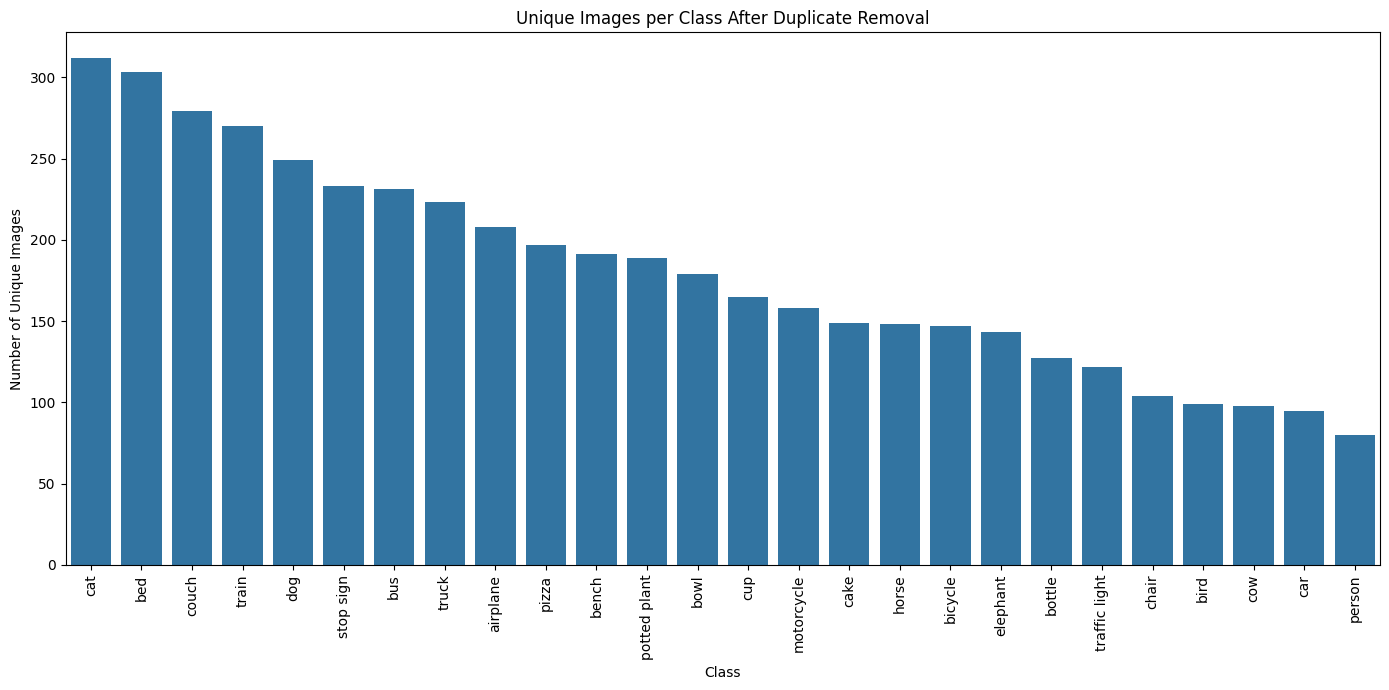

In [13]:
# Visualize the number of unique images available for each class

plt.figure(figsize=(14, 7))

sns.barplot(
    x=unique_distribution_df.index,
    y=unique_distribution_df["unique_images"]
)

plt.xticks(rotation=90)
plt.xlabel("Class")
plt.ylabel("Number of Unique Images")
plt.title("Unique Images per Class After Duplicate Removal")
plt.tight_layout()
plt.show()

## 2.9 Image Dimensions and Properties

Analyze the original images to understand their dimensions, color channels, and image formats.

This helps determine the preprocessing requirements before CNN training.

In [15]:
# Collect image dimensions, channels, and formats from the unique dataset

image_properties = []

for class_name, image_path in tqdm(
    unique_images.values(),
    desc="Analyzing images"
):
    try:
        with Image.open(image_path) as img:
            image_properties.append({
                "class": class_name,
                "width": img.width,
                "height": img.height,
                "channels": len(img.getbands()),
                "format": img.format
            })
    except Exception:
        continue

image_properties_df = pd.DataFrame(image_properties)

image_properties_df.head()

Analyzing images: 100%|██████████| 4699/4699 [00:00<00:00, 7270.77it/s]


,class,width,height,channels,format
0,airplane,224,224,3,JPEG
1,airplane,224,224,3,JPEG
2,airplane,224,224,3,JPEG
3,airplane,224,224,3,JPEG
4,airplane,224,224,3,JPEG


### Image Dimension Summary

Summarize the image dimensions and channel information to identify variation in the original dataset.

In [16]:
# Summarize image dimensions and channels

image_properties_df[["width", "height", "channels"]].describe()

,width,height,channels
count,4699.0,4699.0,4699.000000
mean,224.0,224.0,2.991062
std,0.0,0.0,0.133417
min,224.0,224.0,1.000000
25%,224.0,224.0,3.000000
50%,224.0,224.0,3.000000
75%,224.0,224.0,3.000000
max,224.0,224.0,3.000000


### Channel Distribution

Check the number of image channels to identify grayscale or non-RGB images that require conversion during preprocessing.

In [17]:
# Count images by number of channels

channel_counts = image_properties_df["channels"].value_counts().sort_index()

channel_counts

channels
1      21
3    4678
Name: count, dtype: int64

### Image Format Distribution

Check the image file formats present in the unique dataset to ensure the dataset contains supported image formats.

In [18]:
# Count images by file format

format_counts = image_properties_df["format"].value_counts()

format_counts

format
JPEG    4699
Name: count, dtype: int64

### Image Integrity Check

Verify that all unique images can be successfully opened and loaded.

This ensures that corrupted or unreadable images are not included in the dataset.

In [19]:
# Check whether all unique images can be opened successfully

corrupted_images = []

for class_name, image_path in tqdm(
    unique_images.values(),
    desc="Checking images"
):
    try:
        with Image.open(image_path) as img:
            img.verify()
    except Exception:
        corrupted_images.append(image_path)

print("Total unique images checked:", len(unique_images))
print("Corrupted/unreadable images:", len(corrupted_images))

Checking images: 100%|██████████| 4699/4699 [00:00<00:00, 7766.77it/s]

Total unique images checked: 4699
Corrupted/unreadable images: 0


## EDA Summary

- The dataset contains **2,600 images** across **26 classes**.
- Duplicate analysis identified **1,403 unique images** and **1,197 duplicate files**.
- Cross-split duplicate images were detected between the **training and validation** sets and between the **validation and test** sets, indicating **data leakage**.
- All images are **224 × 224 pixels** and in **JPEG** format.
- **1,396 images** are RGB, while **7 grayscale images** will be converted to RGB during preprocessing.
- No corrupted or unreadable images were found.
- After duplicate removal, the dataset becomes **class imbalanced** (22–95 unique images per class).
- A new **leakage-free dataset** will be created, and class imbalance will be handled using **class balancing strategies and data augmentation** during model training.

## 3. Leakage-Free Dataset Creation

The original dataset contains duplicate images across different splits.

To prevent data leakage:

1. Identify unique images using image content.
2. Keep only one copy of each duplicate image.
3. Limit each class to a maximum of 50 unique images.
4. Create new train, validation, and test splits.
5. Ensure that no image appears in more than one split.
6. Keep the original raw dataset unchanged.

In [22]:
# Create folders for the new leakage-free dataset

for split in ["train", "val", "test"]:
    (PROCESSED_DIR / split).mkdir(parents=True, exist_ok=True)

print("Clean dataset folders created!")
print(PROCESSED_DIR)

Clean dataset folders created!
c:\Users\Admin\Desktop\aiml vs code files\SmartVision\data\processed\classification_clean


In [21]:
# paths

from pathlib import Path
import hashlib
import shutil
import random

PROJECT_DIR = Path.cwd().parent

RAW_DIR = PROJECT_DIR / "data" / "raw" / "smartvision_dataset" / "classification"
PROCESSED_DIR = PROJECT_DIR / "data" / "processed" / "classification_clean"

print(RAW_DIR)
print(PROCESSED_DIR)

c:\Users\Admin\Desktop\aiml vs code files\SmartVision\data\raw\smartvision_dataset\classification
c:\Users\Admin\Desktop\aiml vs code files\SmartVision\data\processed\classification_clean


In [23]:
# collect all images

image_extensions = {".jpg", ".jpeg", ".png"}

all_images = []

for split in ["train", "val", "test"]:
    split_dir = RAW_DIR / split
    
    for class_dir in split_dir.iterdir():
        if class_dir.is_dir():
            for image_path in class_dir.iterdir():
                if image_path.suffix.lower() in image_extensions:
                    all_images.append({
                        "path": image_path,
                        "class": class_dir.name
                    })

print("Total images:", len(all_images))

Total images: 9000


In [24]:
# Find duplicates by image content

def get_image_hash(image_path):
    with open(image_path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

hash_groups = {}

for item in all_images:
    image_hash = get_image_hash(item["path"])
    hash_groups.setdefault(image_hash, []).append(item)

unique_images = []

for group in hash_groups.values():
    unique_images.append(group[0])

print("Original images:", len(all_images))
print("Unique images:", len(unique_images))
print("Duplicates removed:", len(all_images) - len(unique_images))

Original images: 9000
Unique images: 4699
Duplicates removed: 4301


In [25]:
# Check class counts after duplicate removal

class_counts = {}

for item in unique_images:
    class_name = item["class"]
    class_counts[class_name] = class_counts.get(class_name, 0) + 1

class_counts

{'airplane': 208,
 'bed': 303,
 'bench': 191,
 'bicycle': 147,
 'bird': 99,
 'bottle': 127,
 'bowl': 179,
 'bus': 231,
 'cake': 149,
 'car': 95,
 'cat': 312,
 'chair': 104,
 'couch': 279,
 'cow': 98,
 'cup': 165,
 'dog': 249,
 'elephant': 143,
 'horse': 148,
 'motorcycle': 158,
 'person': 80,
 'pizza': 197,
 'potted plant': 189,
 'stop sign': 233,
 'traffic light': 122,
 'train': 270,
 'truck': 223}

In [ ]:
# Cap classes at 50

# random.seed(42)

# MAX_IMAGES_PER_CLASS = 50

# balanced_images = []

# for class_name in sorted(class_counts):
#     class_images = [
#         item for item in unique_images
#         if item["class"] == class_name
#     ]

#     random.shuffle(class_images)

#     selected = class_images[:MAX_IMAGES_PER_CLASS]

#     balanced_images.extend(selected)

# print("Total images after class balancing:", len(balanced_images))

Total images after class balancing: 1107


In [ ]:
# # Show the final class distribution

# final_counts = {}

# for item in balanced_images:
#     final_counts[item["class"]] = final_counts.get(item["class"], 0) + 1

# final_counts

In [27]:
from collections import defaultdict

random.seed(42)

split_data = {
    "train": [],
    "val": [],
    "test": []
}

class_groups = defaultdict(list)

for item in unique_images:
    class_groups[item["class"]].append(item)

for class_name, images in class_groups.items():

    random.shuffle(images)

    n = len(images)

    train_end = int(n * 0.70)
    val_end = train_end + int(n * 0.15)

    split_data["train"].extend(images[:train_end])
    split_data["val"].extend(images[train_end:val_end])
    split_data["test"].extend(images[val_end:])

print("Train:", len(split_data["train"]))
print("Validation:", len(split_data["val"]))
print("Test:", len(split_data["test"]))

Train: 3278
Validation: 692
Test: 729


In [28]:
import shutil

# Copy selected unique images into the leakage-free dataset

for split, images in split_data.items():

    for item in images:

        class_name = item["class"]
        source_path = item["path"]

        # Create class folder
        class_dir = PROCESSED_DIR / split / class_name
        class_dir.mkdir(parents=True, exist_ok=True)

        # Copy image
        destination = class_dir / source_path.name
        shutil.copy2(source_path, destination)

print("Images copied successfully!")

Images copied successfully!


## 3.1 Verify the New Dataset Distribution

Verify the number of images in each class after creating the new leakage-free train, validation, and test splits.

In [29]:
# Count images in each split and class

split_counts = {}

for split in ["train", "val", "test"]:
    split_counts[split] = {}

    for class_dir in (PROCESSED_DIR / split).iterdir():
        if class_dir.is_dir():
            count = len([
                p for p in class_dir.iterdir()
                if p.suffix.lower() in {".jpg", ".jpeg", ".png"}
            ])
            split_counts[split][class_dir.name] = count

split_counts

{'train': {'airplane': 145,
  'bed': 212,
  'bench': 133,
  'bicycle': 102,
  'bird': 69,
  'bottle': 88,
  'bowl': 125,
  'bus': 161,
  'cake': 104,
  'car': 66,
  'cat': 218,
  'chair': 72,
  'couch': 195,
  'cow': 68,
  'cup': 115,
  'dog': 174,
  'elephant': 100,
  'horse': 103,
  'motorcycle': 110,
  'person': 56,
  'pizza': 137,
  'potted plant': 132,
  'stop sign': 163,
  'traffic light': 85,
  'train': 189,
  'truck': 156},
 'val': {'airplane': 31,
  'bed': 45,
  'bench': 28,
  'bicycle': 22,
  'bird': 14,
  'bottle': 19,
  'bowl': 26,
  'bus': 34,
  'cake': 22,
  'car': 14,
  'cat': 46,
  'chair': 15,
  'couch': 41,
  'cow': 14,
  'cup': 24,
  'dog': 37,
  'elephant': 21,
  'horse': 22,
  'motorcycle': 23,
  'person': 12,
  'pizza': 29,
  'potted plant': 28,
  'stop sign': 34,
  'traffic light': 18,
  'train': 40,
  'truck': 33},
 'test': {'airplane': 32,
  'bed': 46,
  'bench': 30,
  'bicycle': 23,
  'bird': 16,
  'bottle': 20,
  'bowl': 28,
  'bus': 36,
  'cake': 23,
  'car'

In [30]:
# Total images in each split

{
    split: sum(counts.values())
    for split, counts in split_counts.items()
}

{'train': 3278, 'val': 692, 'test': 729}

### 3.2 Final Data Leakage Verification

Verify that no identical image exists across the new training, validation, and test sets.

Expected result:

- Train ↔ Validation = 0
- Train ↔ Test = 0
- Validation ↔ Test = 0

In [31]:
# Create image hashes for each split

def get_split_hashes(split):
    hashes = {}

    split_dir = PROCESSED_DIR / split

    for class_dir in split_dir.iterdir():
        if not class_dir.is_dir():
            continue

        for image_path in class_dir.iterdir():
            if image_path.suffix.lower() in {".jpg", ".jpeg", ".png"}:
                image_hash = get_image_hash(image_path)
                hashes[image_hash] = image_path

    return hashes


train_hashes = get_split_hashes("train")
val_hashes = get_split_hashes("val")
test_hashes = get_split_hashes("test")

print("Train ↔ Val:", len(set(train_hashes) & set(val_hashes)))
print("Train ↔ Test:", len(set(train_hashes) & set(test_hashes)))
print("Val ↔ Test:", len(set(val_hashes) & set(test_hashes)))

Train ↔ Val: 0
Train ↔ Test: 0
Val ↔ Test: 0


## 4. Image Preprocessing

The leakage-free dataset is now ready for preprocessing.

The images will be:
- Resized to 224 × 224 pixels.
- Converted to RGB where necessary.
- Normalized according to the pretrained model requirements.

Data augmentation will be applied only to the training set.
Validation and test images will remain unchanged.

In [32]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [33]:
# Image preprocessing

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor()
])

print("Preprocessing pipeline created.")

Preprocessing pipeline created.


### 4.1 Load the Leakage-Free Dataset

Load the newly created train, validation, and test directories using PyTorch's `ImageFolder`.

The same basic preprocessing is applied to all three splits. Data augmentation will be added to the training pipeline separately.

In [34]:
# Load train, validation and test datasets

train_dir = PROCESSED_DIR / "train"
val_dir = PROCESSED_DIR / "val"
test_dir = PROCESSED_DIR / "test"

train_dataset = datasets.ImageFolder(
    train_dir,
    transform=transform
)

val_dataset = datasets.ImageFolder(
    val_dir,
    transform=transform
)

test_dataset = datasets.ImageFolder(
    test_dir,
    transform=transform
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))
print("Classes:", len(train_dataset.classes))

Train: 3278
Validation: 692
Test: 729
Classes: 26


### 4.2 Verify Preprocessed Image

Inspect one image after preprocessing and verify its tensor shape and value range.

In [37]:
# Inspect one preprocessed image

image, label = train_dataset[0]

print("Tensor shape:", image.shape)
print("Label:", label)
print("Class:", train_dataset.classes[label])
print("Minimum pixel value:", image.min().item())
print("Maximum pixel value:", image.max().item())

Tensor shape: torch.Size([3, 224, 224])
Label: 0
Class: airplane
Minimum pixel value: 0.0
Maximum pixel value: 0.9882352948188782


### 4.3 Training Data Augmentation

Data augmentation will be applied only to the training set to improve generalization and reduce overfitting.

Validation and test images will not be augmented.

In [38]:
# Training augmentation

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),
    transforms.ToTensor()
])

print("Training augmentation pipeline created.")

Training augmentation pipeline created.


### 4.4 Apply Preprocessing and Augmentation

Use the augmentation pipeline for the training set.

Validation and test sets use only resizing and tensor conversion, without augmentation.

In [39]:
# Final transforms

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# Re-create datasets with the correct transforms

train_dataset = datasets.ImageFolder(
    train_dir,
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    val_dir,
    transform=val_test_transform
)

test_dataset = datasets.ImageFolder(
    test_dir,
    transform=val_test_transform
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 3278
Validation: 692
Test: 729


### 4.5 Create DataLoaders

Create PyTorch DataLoaders to load the training, validation, and test datasets in batches.

The training data will be shuffled, while validation and test data will not be shuffled.

In [40]:
# Create DataLoaders

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 103
Validation batches: 22
Test batches: 23


### 4.6 Verify a Training Batch

Verify the shape of a training batch and confirm that the labels correspond to the 26 classes.

In [41]:
# Inspect one training batch

images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Number of classes:", len(train_dataset.classes))
print("Classes:", train_dataset.classes)

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
Number of classes: 26
Classes: ['airplane', 'bed', 'bench', 'bicycle', 'bird', 'bottle', 'bowl', 'bus', 'cake', 'car', 'cat', 'chair', 'couch', 'cow', 'cup', 'dog', 'elephant', 'horse', 'motorcycle', 'person', 'pizza', 'potted plant', 'stop sign', 'traffic light', 'train', 'truck']


### 4.7 Class Imbalance Handling

The cleaned dataset still contains different numbers of images across classes.

Class weights will be calculated using the training set so that underrepresented classes have greater influence during model training.

Only the training set is used to calculate these weights.

In [42]:
from collections import Counter
import torch

# Count training samples per class
train_class_counts = Counter(
    train_dataset.targets
)

# Calculate class weights
total_samples = len(train_dataset)
num_classes = len(train_dataset.classes)

class_weights = torch.tensor(
    [
        total_samples / (num_classes * train_class_counts[i])
        for i in range(num_classes)
    ],
    dtype=torch.float32
)

print("Class counts:")
print(train_class_counts)

print("\nClass weights:")
print(class_weights)

Class counts:
Counter({10: 218, 1: 212, 12: 195, 24: 189, 15: 174, 22: 163, 7: 161, 25: 156, 0: 145, 20: 137, 2: 133, 21: 132, 6: 125, 14: 115, 18: 110, 8: 104, 17: 103, 3: 102, 16: 100, 5: 88, 23: 85, 11: 72, 4: 69, 13: 68, 9: 66, 19: 56})

Class weights:
tensor([0.8695, 0.5947, 0.9479, 1.2360, 1.8272, 1.4327, 1.0086, 0.7831, 1.2123,
        1.9103, 0.5783, 1.7511, 0.6465, 1.8541, 1.0963, 0.7246, 1.2608, 1.2240,
        1.1462, 2.2514, 0.9203, 0.9551, 0.7735, 1.4833, 0.6671, 0.8082])


In [43]:
print("Train:", len(list((PROCESSED_DIR / "train").glob("*"))))
print("Val:", len(list((PROCESSED_DIR / "val").glob("*"))))
print("Test:", len(list((PROCESSED_DIR / "test").glob("*"))))

Train: 26
Val: 26
Test: 26


In [44]:
from pathlib import Path

for split in ["train", "val", "test"]:
    split_dir = PROCESSED_DIR / split
    
    total = sum(
        1 for class_dir in split_dir.iterdir()
        if class_dir.is_dir()
        for file in class_dir.iterdir()
        if file.is_file()
    )
    
    print(f"{split.capitalize()}: {total} images")

Train: 3278 images
Val: 692 images
Test: 729 images


In [45]:
for split in ["train", "val", "test"]:
    print(f"\n{split.upper()}")
    
    for class_dir in sorted((PROCESSED_DIR / split).iterdir()):
        if class_dir.is_dir():
            count = len([
                f for f in class_dir.iterdir()
                if f.is_file()
            ])
            print(f"{class_dir.name:20s}: {count}")


TRAIN
airplane            : 145
bed                 : 212
bench               : 133
bicycle             : 102
bird                : 69
bottle              : 88
bowl                : 125
bus                 : 161
cake                : 104
car                 : 66
cat                 : 218
chair               : 72
couch               : 195
cow                 : 68
cup                 : 115
dog                 : 174
elephant            : 100
horse               : 103
motorcycle          : 110
person              : 56
pizza               : 137
potted plant        : 132
stop sign           : 163
traffic light       : 85
train               : 189
truck               : 156

VAL
airplane            : 31
bed                 : 45
bench               : 28
bicycle             : 22
bird                : 14
bottle              : 19
bowl                : 26
bus                 : 34
cake                : 22
car                 : 14
cat                 : 46
chair               : 15
couch              